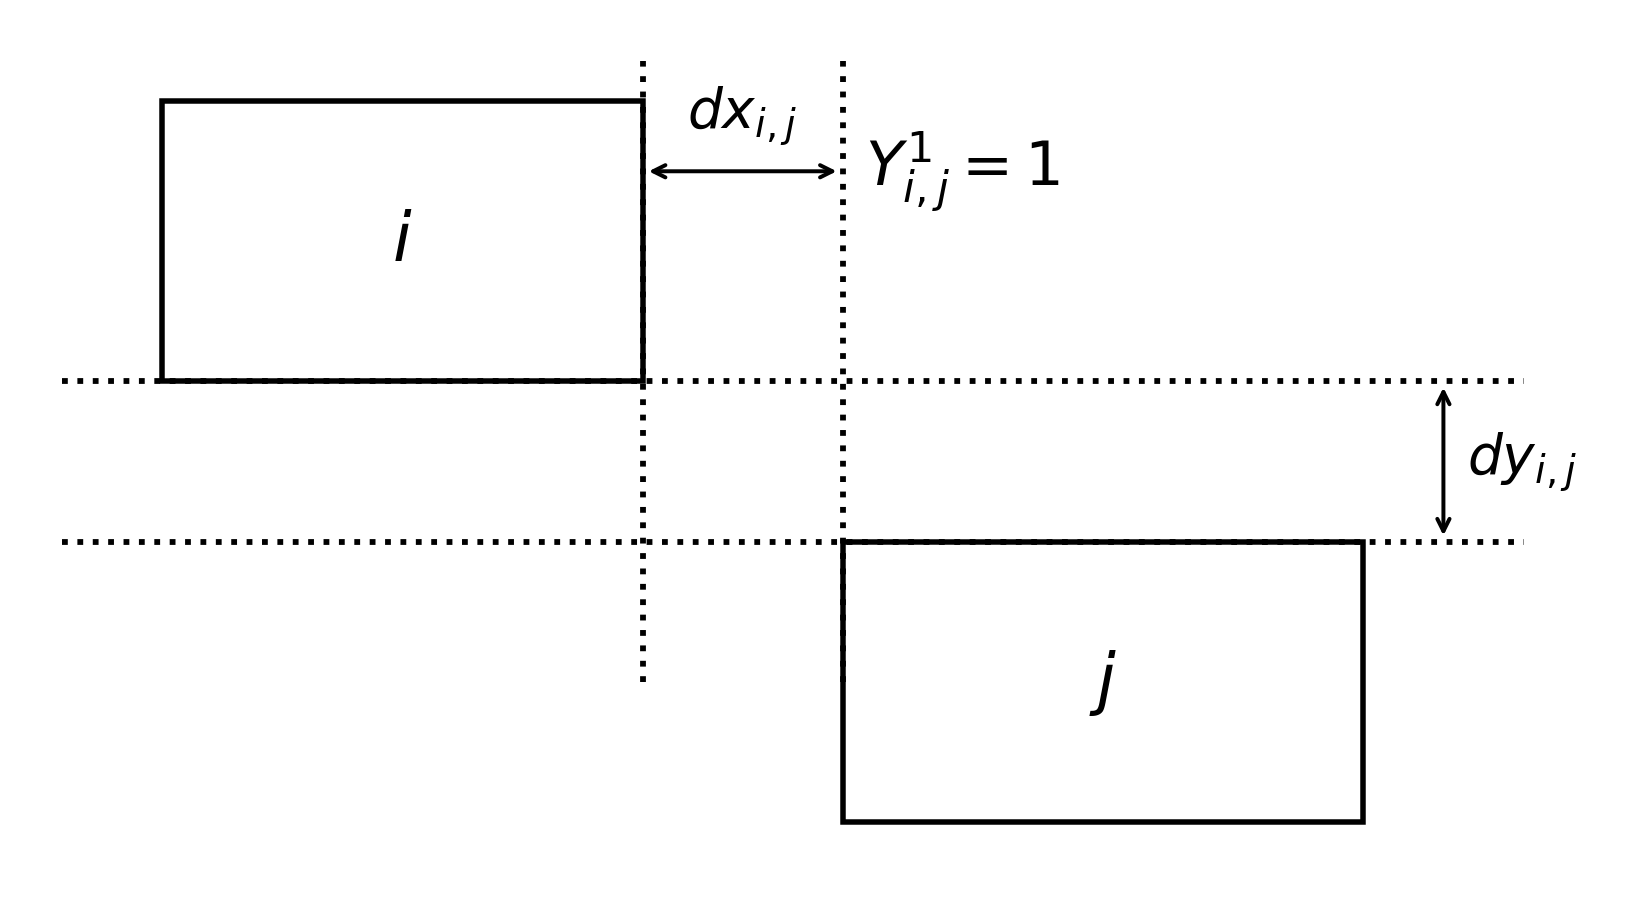

\begin{gather}
\min \; \lambda\,(l_f + w_f) + \sum_{i,j} c_{i,j}( dx_{i,j} + dy_{i,j}) \\
\text{Minimize the weighted plant size plus cost-weighted Manhattan pipe distances ($\lambda = 1$ by default)}\\
\textrm{s.t.} \;l_f \ge y_i + l_i \; \forall  i \in  N \\
\text{Plant length (the vertical $y$ axis) contains every block}\\ 
w_f \ge x_i + w_i \; \forall  i \in  N \\ 
\text{Plant width (the horizontal $x$ axis) contains every block}\\
y_1 = 0, \quad l_f = l_1 \\
\text{The pipe rack (block 1) spans the plant length: pinned at $y=0$ with the plant length fixed to the rack}\\
dx_{i,j} \ge x_i - (x_j + w_j), \quad dx_{i,j} \ge x_j - (x_i + w_i) \; \forall i,j \in N,\, j<i \\
dy_{i,j} \ge y_i - (y_j + l_j), \quad dy_{i,j} \ge y_j - (y_i + l_i) \; \forall i,j \in N,\, j<i \\
\text{Rectilinear edge gaps (0 when blocks overlap on that axis), defined globally, not inside the disjunction}\\
x_i \le UB, \; y_i \le UB \; \forall i \in  N, \quad UB = \sum_{i} \max(l_i,w_i) \\ 
\left[
\begin{array}{c}
Y_{i,j}^1\\
x_i + w_i + d_{i,j} \le x_j\\ 
y_i + l_i \ge y_j - (d_{i,j}-1)\\
y_j + l_j \ge y_i - (d_{i,j}-1)\\
\text{$i$ is left of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^2\\
x_j + w_j + d_{i,j} \le x_i\\ 
y_i + l_i \ge y_j - (d_{i,j}-1)\\
y_j + l_j \ge y_i - (d_{i,j}-1)\\
\text{$i$ is right of $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^3 \\
y_i + l_i + d_{i,j} \le y_j \\ 
\text{$i$ is below $j$}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i,j}^4 \\
y_j + l_j + d_{i,j} \le y_i \\ 
\text{$i$ is above $j$}
\end{array}
\right] \\
\text{Non-overlap: one separation per pair, with the minimum clearance $d_{i,j}$ built in. The left/right disjuncts also force vertical overlap within $d_{i,j}-1$ (a degeneracy breaking constraint)}\\
\\
\left[
\begin{array}{c}
Y_{i}^5 \\
l_i = l^0_i \\
w_i = w^0_i\\
\text{Default orientation}
\end{array}
\right]
\lor
\left[
\begin{array}{c}
Y_{i}^6\\
l_i = w^0_i \\
w_i = l^0_i \\
\text{Rotated orientation}
\end{array}
\right] \; \forall i \in N \setminus \{1\} \\ 
\\
l_f,w_f,l_i,w_i,x_i,y_i,dx_{i,j},dy_{i,j} \in \mathbb{R}^1_+ \\
Y_{i,j}^1,Y_{i,j}^2,Y_{i,j}^3,Y_{i,j}^4,Y_{i}^5,Y_{i}^6 \in \text{ \{ True, False \}  } \\
\forall i,j \in N, j <i
\end{gather}

Length is the vertical ($y$) axis and width the horizontal ($x$) axis. Distance is handled by the global $dx,dy$ constraints, so the disjunction decides only non-overlap, never cost. This keeps the objective independent of which spatial relation is chosen, and avoids the costly *continuous* degeneracy that coupling distance into the disjuncts would create. The left/right disjuncts additionally force the two blocks to overlap vertically within $d_{i,j}-1$. This is a **degeneracy breaking constraint**, the $d$-aware form of Trespalacios & Grossmann. A diagonally separated pair then has a vertical gap $\ge d_{i,j}$ and can only be encoded as above/below, so each physical layout has a single encoding instead of several. It is optimum-preserving and relies on integer $d$, and it keeps branch-and-bound from re-exploring duplicate encodings of the same layout. The pipe rack (block 1) spans the plant length and keeps a fixed orientation even when rotation is on, so the rotation disjunction applies to blocks $2 \ldots n$ only. Symmetry breaking (when `sym=1`) anchors block 1 left-of-and-below block 2: $x_1 + w_1/2 \le x_2 + w_2/2$ and $y_1 + l_1/2 \le y_2 + l_2/2$. The footprint weight $\lambda$ defaults to 1. Raise it to favor a smaller plant over cheaper piping.

In [1]:
import random
import pandas as pd
import visuals as vs
from pyomo.environ import (ConcreteModel, NonNegativeReals, Objective, Param,
                           Set, SolverFactory, TransformationFactory, Var, value, RangeSet)
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patheffects as pe


def create_model(n, w_0, l_0, c_0, d_0, rotate=0, sym=0, footprint_weight=1.0):

    ## Model
    m = ConcreteModel()

    ## Sets
    m.n = Set(ordered=True, initialize=RangeSet(1, n))
    def rec_pairs_filter(m, i, j):
        return i > j
    m.p = Set(initialize=m.n * m.n, dimen=2, filter=rec_pairs_filter)

    ## Parameters
    # Default-orientation width and length of each block
    m.w0 = Param(m.n, initialize=w_0)
    m.l0 = Param(m.n, initialize=l_0)
    # Pipe cost per pair (star topology: each block pipes to the rack, block 1)
    m.c = Param(m.p, initialize=c_0)
    # Minimum separation distance per pair
    m.d = Param(m.p, initialize=d_0)
    # Conservative upper bound on coordinates
    m.UB = Param(initialize=sum(max([m.l0[i], m.w0[i]]) for i in m.n))

    ## Variables
    # Lower-left corner: x is the horizontal (width) axis, y the vertical (length) axis
    m.x = Var(m.n, bounds=(0, m.UB))
    m.y = Var(m.n, bounds=(0, m.UB))
    # Rectilinear edge gaps between each pair (horizontal dx, vertical dy)
    m.dx = Var(m.p, bounds=(0, m.UB))
    m.dy = Var(m.p, bounds=(0, m.UB))
    # Block length (vertical extent) and width (horizontal extent)
    m.l = Var(m.n, bounds=(0, m.UB))
    m.w = Var(m.n, bounds=(0, m.UB))
    # Plant length (vertical) and width (horizontal)
    m.l_f = Var(within=NonNegativeReals)
    m.w_f = Var(within=NonNegativeReals)

    ## Constraints
    # Plant bounding box: length is the vertical (y) axis, width the horizontal (x)
    @m.Constraint(m.n)
    def plant_length(m, i):
        return m.l_f >= m.y[i] + m.l[i]
    @m.Constraint(m.n)
    def plant_width(m, i):
        return m.w_f >= m.x[i] + m.w[i]

    # Pipe rack (block 1) spans the plant length: pinned at y=0 with the
    # plant length fixed to the rack. Only the plant width is minimized.
    @m.Constraint()
    def rack_at_origin(m):
        return m.y[1] == 0
    @m.Constraint()
    def plant_len_eq_rack(m):
        return m.l_f == m.l[1]

    # Rectilinear edge gaps, defined globally so the objective never depends on
    # which spatial relation the disjunction picks. Each is minimized, so it
    # settles to the true clearance (0 if the blocks overlap on that axis).
    @m.Constraint(m.p)
    def dx_lb_a(m, i, j):
        return m.dx[i,j] >= m.x[i] - (m.x[j] + m.w[j])
    @m.Constraint(m.p)
    def dx_lb_b(m, i, j):
        return m.dx[i,j] >= m.x[j] - (m.x[i] + m.w[i])
    @m.Constraint(m.p)
    def dy_lb_a(m, i, j):
        return m.dy[i,j] >= m.y[i] - (m.y[j] + m.l[j])
    @m.Constraint(m.p)
    def dy_lb_b(m, i, j):
        return m.dy[i,j] >= m.y[j] - (m.y[i] + m.l[i])

    # Symmetry breaking: anchor block 1 left-of-and-below block 2's center.
    if sym == 1:
        @m.Constraint()
        def sym_1(m):
            return m.x[1] + m.w[1]/2 <= m.x[2] + m.w[2]/2
        @m.Constraint()
        def sym_2(m):
            return m.y[1] + m.l[1]/2 <= m.y[2] + m.l[2]/2

    ## Objective: weighted plant size + cost-weighted Manhattan piping.
    ## footprint_weight (default 1) trades plant size against piping cost.
    m.obj = Objective(expr=footprint_weight * (m.l_f + m.w_f)
                      + sum(m.c[i,j] * (m.dx[i,j] + m.dy[i,j]) for i,j in m.p))

    # Non-overlap: a 4-way disjunction per pair (one spatial relation each, with
    # the minimum clearance d baked in). The left/right disjuncts also carry the
    # degeneracy breaking constraint (the d-aware form of Trespalacios & Grossmann): the two
    # blocks must overlap vertically within d-1, so a diagonally separated pair
    # (vertical gap >= d) can only route through above/below. That gives one
    # encoding per physical layout instead of several, so branch-and-bound does
    # not waste effort on duplicate encodings of the same layout. It is
    # optimum-preserving and valid because d is integer.
    @m.Disjunction(m.p)
    def no_overlap(m, i, j):
        vov = [m.y[i] + m.l[i] >= m.y[j] - (m.d[i,j] - 1),
               m.y[j] + m.l[j] >= m.y[i] - (m.d[i,j] - 1)]
        return [
            [m.x[i] + m.w[i] + m.d[i,j] <= m.x[j]] + vov,   # i left of j
            [m.x[j] + m.w[j] + m.d[i,j] <= m.x[i]] + vov,   # i right of j
            [m.y[i] + m.l[i] + m.d[i,j] <= m.y[j]],         # i below j
            [m.y[j] + m.l[j] + m.d[i,j] <= m.y[i]],         # i above j
            ]

    # Rotation (optional): a 2-way orientation disjunction per block, except the
    # rack (block 1), which keeps its orientation even when rotation is on.
    if rotate:
        rot_blocks = [i for i in m.n if i != 1]
        @m.Disjunction(rot_blocks)
        def rotation(m, i):
            return [
                [m.l[i] == m.l0[i], m.w[i] == m.w0[i]],   # default orientation
                [m.l[i] == m.w0[i], m.w[i] == m.l0[i]],   # 90 degrees rotated
                ]
        @m.Constraint()
        def fix_rack_l(m):
            return m.l[1] == m.l0[1]
        @m.Constraint()
        def fix_rack_w(m):
            return m.w[1] == m.w0[1]
    else:
        @m.Constraint(m.n)
        def fix_l(m, i):
            return m.l[i] == m.l0[i]
        @m.Constraint(m.n)
        def fix_w(m, i):
            return m.w[i] == m.w0[i]
    return m

In [2]:
# Default instance: the pipe rack (block 1) plus 14 objects. The rack is the
# longest block (length 9, width 1) and spans the plant.
num = 15

# Length (vertical extent) and width (horizontal extent) of each block
l_0 = {1: 9, 2: 1, 3: 2, 4: 2, 5: 2, 6: 2, 7: 2, 8: 3,
       9: 3, 10: 1, 11: 1, 12: 3, 13: 3, 14: 3, 15: 1}
w_0 = {1: 1, 2: 3, 3: 1, 4: 2, 5: 1, 6: 1, 7: 3, 8: 2,
       9: 1, 10: 2, 11: 1, 12: 1, 13: 1, 14: 1, 15: 2}

# Star topology: every block pipes to the rack (block 1) only, so cost(i, 1) > 0
# for i >= 2 and every other pair is 0.
rack_cost = {2: 1, 3: 2, 4: 3, 5: 1, 6: 2, 7: 1, 8: 2,
             9: 3, 10: 1, 11: 3, 12: 2, 13: 2, 14: 3, 15: 2}
c_0 = {(i, j): (rack_cost[i] if j == 1 else 0)
       for i in range(1, num + 1) for j in range(1, num + 1) if i > j}

# Minimum separation distance for every pair
d_0 = {(i, j): 1 for i in range(1, num + 1) for j in range(1, num + 1) if i > j}

In [3]:
m = create_model(num, w_0, l_0, c_0, d_0, rotate=0, sym=1)
TransformationFactory('gdp.bigm').apply_to(m)

# HiGHS is the open-source MILP solver (pip install highspy). The native appsi
# interface respects the time limit and still loads a timed-out incumbent. On
# this instance HiGHS may hit the limit before proving optimality.
from pyomo.contrib.appsi.solvers import Highs

opt = Highs()
opt.config.time_limit = 60
opt.config.load_solution = False
opt.config.stream_solver = True
res = opt.solve(m)
if res.best_feasible_objective is not None:
    res.solution_loader.load_vars()

print("termination:", res.termination_condition)
print("objective:  ", res.best_feasible_objective)

Running HiGHS 1.14.0 (git hash: 7df0786): Copyright (c) 2026 under MIT licence terms


MIP has 1429 rows; 692 cols; 5591 nonzeros; 420 integer variables (420 binary)
Coefficient ranges:
  Matrix  [5e-01, 9e+01]
  Cost    [1e+00, 3e+00]
  Bound   [1e+00, 4e+01]
  RHS     [1e+00, 9e+01]
Presolving model
1311 rows, 450 cols, 3602 nonzeros 0s
883 rows, 422 cols, 2724 nonzeros 0s
883 rows, 422 cols, 2724 nonzeros 0s
Presolve reductions: rows 883(-546); columns 422(-270); nonzeros 2724(-2867) 

Solving MIP model with:
   883 rows
   422 cols (378 binary, 0 integer, 0 implied int., 44 continuous, 0 domain fixed)
   2724 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; z => Trivial zero

        Nodes      |    B&B Tree     |            Objective Bounds            

 L       0       0         0   0.00%   39.71428571     143               72.23%     7293    393     51      1719     0.6s

0.3% inactive integer columns, restarting
Model after restart has 881 rows, 421 cols (377 bin., 0 int., 0 impl., 44 cont., 0 dom.fix.), and 2718 nonzeros

         0       0         0   0.00%   39.71428571     143               72.23%      145      0      0      4043     0.6s
         0       0         0   0.00%   39.71428571     143               72.23%      145     82      2      4230     0.6s



Symmetry detection completed in 0.0s
Found 3 generator(s)



 T     477     128       141   0.01%   42.06994536     141               70.16%     9715    297    860     32518     3.4s
 B     488     104       147   0.01%   42.06994536     137               69.29%     9729    297    887     32953     3.5s


...

 L   10084     462      1022   0.06%   42.16666667     87                51.53%     9865    238   3685    305847    47.4s


     10403     529      1129   0.06%   42.16666667     87                51.53%    10006    178   4120    341074    52.9s


     10800     590      1277   0.06%   42.16666667     87                51.53%    10359    139   4623    364233    59.5s

Restarting search from the root node
Model after restart has 881 rows, 421 cols (377 bin., 0 int., 0 impl., 44 cont., 0 dom.fix.), and 2718 nonzeros

     10895       0         0   0.00%   42.16666667     87                51.53%      139      0      0    365689    59.7s
     10895       0         0   0.00%   42.16666667     87                51.53%      139     43      2    365763    59.7s



Symmetry detection completed in 0.0s
Found 3 generator(s)

     10976      21        25   0.06%   42.20689655     87                51.49%     7577    213     62    368458    60.0s

Solving report
  Status            Time limit reached
  Primal bound      87
  Dual bound        42.2068965517
  Gap               51.49% (tolerance: 0.01%)
  P-D integral      32.7977015599
  Solution status   feasible
                    87 (objective)
                    0 (bound viol.)
                    1.88737914186e-15 (int. viol.)
                    0 (row viol.)
  Timing            60.00
  Max sub-MIP depth 7
  Nodes             10976
  Repair LPs        1 (1 feasible; 25 iterations)
  LP iterations     368458
                    42167 (strong br.)
                    27875 (separation)
                    133024 (heuristics)


termination: TerminationCondition.maxTimeLimit
objective:   86.99999999999967


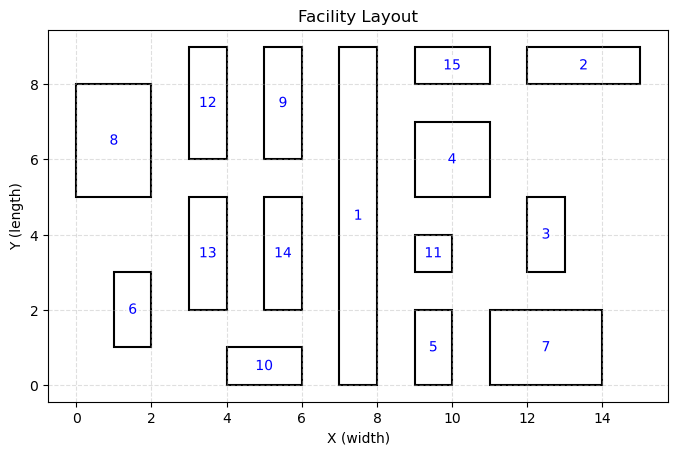

,Rectangle,X (Lower Left),Y (Lower Left),Width (X),Length (Y)
0,1,7,0,1,9
1,2,12,8,3,1
2,3,12,3,1,2
3,4,9,5,2,2
4,5,9,0,1,2
5,6,1,1,1,2
6,7,11,0,3,2
7,8,0,5,2,3
8,9,5,6,1,3
9,10,4,0,2,1


In [4]:
vs.plot_rect_layout(m, title="Plant Layout")
vs.rect_table(m,decimals = 0)

In [5]:
print(c_0)

{(2, 1): 1, (3, 1): 2, (3, 2): 0, (4, 1): 3, (4, 2): 0, (4, 3): 0, (5, 1): 1, (5, 2): 0, (5, 3): 0, (5, 4): 0, (6, 1): 2, (6, 2): 0, (6, 3): 0, (6, 4): 0, (6, 5): 0, (7, 1): 1, (7, 2): 0, (7, 3): 0, (7, 4): 0, (7, 5): 0, (7, 6): 0, (8, 1): 2, (8, 2): 0, (8, 3): 0, (8, 4): 0, (8, 5): 0, (8, 6): 0, (8, 7): 0, (9, 1): 3, (9, 2): 0, (9, 3): 0, (9, 4): 0, (9, 5): 0, (9, 6): 0, (9, 7): 0, (9, 8): 0, (10, 1): 1, (10, 2): 0, (10, 3): 0, (10, 4): 0, (10, 5): 0, (10, 6): 0, (10, 7): 0, (10, 8): 0, (10, 9): 0, (11, 1): 3, (11, 2): 0, (11, 3): 0, (11, 4): 0, (11, 5): 0, (11, 6): 0, (11, 7): 0, (11, 8): 0, (11, 9): 0, (11, 10): 0, (12, 1): 2, (12, 2): 0, (12, 3): 0, (12, 4): 0, (12, 5): 0, (12, 6): 0, (12, 7): 0, (12, 8): 0, (12, 9): 0, (12, 10): 0, (12, 11): 0, (13, 1): 2, (13, 2): 0, (13, 3): 0, (13, 4): 0, (13, 5): 0, (13, 6): 0, (13, 7): 0, (13, 8): 0, (13, 9): 0, (13, 10): 0, (13, 11): 0, (13, 12): 0, (14, 1): 3, (14, 2): 0, (14, 3): 0, (14, 4): 0, (14, 5): 0, (14, 6): 0, (14, 7): 0, (14, 8): 